# Notebook 2: Custom CNN Architecture and Training

## 🎯 Objective 3 & 4
This notebook covers the core deep learning implementation:
1. **Data Loading:** Re-establishing the datasets and DataLoaders.
2. **Model Architecture:** Designing a custom Convolutional Neural Network (CNN) from scratch using PyTorch.
3. **Training & Validation:** Running the training loop, calculating loss, and tracking accuracy.
4. **Evaluation:** Plotting performance graphs, generating a Confusion Matrix, and creating a Classification Report to detect overfitting/underfitting.

In [1]:
# Import required libraries
import copy
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Set up device configuration for GPU acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware utilized for training: {device}")

Hardware utilized for training: cuda


## 1. Recreate DataLoaders
To keep this notebook independent, the dataset and DataLoaders from Notebook 1 are re-initialized here. The exact same 80/10/10 split and deepcopy logic is applied to ensure data integrity.

In [2]:
# dataset path
dataset_path = "../dataset/plantvillage-dataset/color"

# 1. Define Transforms (Notebook 1 cell-7)

# Define transformations for the Training set (includes augmentation)
train_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),  # Flip images left-to-right randomly
        transforms.RandomRotation(15),  # Rotate images by up to 15 degrees
        transforms.ToTensor(),  # Convert image to PyTorch Tensor (scales pixels 0 to 1)
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        ),  # Standard ImageNet normalization
    ]
)

# Define transformations for Validation/Test sets (NO augmentation, just resize and normalize)
test_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

print("Transforms defined successfully.")

# Notebook 1 cell-9
# 2. Load Full Dataset

# Load the dataset using ImageFolder (it automatically assigns labels based on folder names)
full_dataset = datasets.ImageFolder(root=dataset_path, transform=train_transforms)

class_names = full_dataset.classes
num_classes = len(class_names)

# 3. Calculate Splits
# Calculate the sizes for our 80/10/10 split
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

# 4. Perform random Split

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42),  # Seed for reproducibility
)

# 5. Apply isolated transforms to Validation and Test sets

# Deepcopy the datasets so we don't overwrite the training augmentations
val_dataset.dataset = copy.deepcopy(full_dataset)
val_dataset.dataset.transform = test_transforms

test_dataset.dataset = copy.deepcopy(full_dataset)
test_dataset.dataset.transform = test_transforms

# 6. Create DataLoaders to load data in batches
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Save the class names mapping for later use in our Flask app
print(f"Number of classes detected: {num_classes}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

print("DataLoaders are ready!")

Transforms defined successfully.
Number of classes detected: 38
Training batches: 1358
Validation batches: 170
Test batches: 170
DataLoaders are ready!


## 2. Custom CNN Architecture
The network processes standard 224x224 RGB images. It extracts visual features (like leaf texture and disease spots) using four convolutional blocks. 

Each block contains:
* **Conv2d:** Extracts features using filters.
* **BatchNorm2d:** Normalizes the layer inputs to stabilize and speed up training.
* **ReLU:** Activation function to introduce non-linearity.
* **MaxPool2d:** Downsamples the image to reduce computation.

Finally, an `AdaptiveAvgPool2d` ensures the output size is predictable before flattening it into the Dense (Linear) classification layers.

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=38):
        super(CustomCNN, self).__init__()

        # Feature Extraction Layers
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Classification Layers
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # Shrinks spatial dimensions to 1x1
            nn.Flatten(),  # Flattens the 256x1x1 tensor to a 1D vector of 256
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.5),  # Regularization to prevent overfitting
            nn.Linear(512, num_classes),  # Final output layer for 38 classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Initialize the model and move it to the GPU
model = CustomCNN(num_classes=num_classes).to(device)
print(model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

## 3. Training Preparation
Define the loss function and the optimizer. 
* **Loss Function:** `CrossEntropyLoss` is standard for multi-class classification.
* **Optimizer:** `Adam` optimizer with a learning rate of 0.001.

In [4]:
# Hyperparameters
learning_rate = 0.001
num_epochs = 20

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Tracking history for plotting later
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

# Ensure the models directory exists for saving weights
os.makedirs("../models", exist_ok=True)
best_model_path = "../models/custom_cnn.pth"

## 4. Training Loop
The training loop iterates over the dataset. For each epoch, it performs a training phase (updating weights) and a validation phase (evaluating performance without updating weights). The best model state is saved based on validation accuracy.

In [5]:
best_val_acc = 0.0

print("Starting Training...")
for epoch in range(num_epochs):

    # ================= Training Phase =================
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients to prevent accumulation
        optimizer.zero_grad()

        # Forward pass: compute predictions
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass: compute gradients
        loss.backward()

        # Optimize: update weights
        optimizer.step()

        # Calculate statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train

    # ================= Validation Phase =================
    model.eval()  # Set model to evaluation mode (disables dropout, etc.)
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Disable gradient calculation for validation to save memory and compute
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val

    # Save history
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_acc"].append(epoch_val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}"
    )

    # Save the model if validation accuracy improves
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"--> Saved improved model with Val Acc: {best_val_acc:.4f}")

print("Training Complete!")

Starting Training...
Epoch [1/20] Train Loss: 1.1985, Train Acc: 0.6427 | Val Loss: 0.6465, Val Acc: 0.7873
--> Saved improved model with Val Acc: 0.7873
Epoch [2/20] Train Loss: 0.5999, Train Acc: 0.8111 | Val Loss: 0.5743, Val Acc: 0.8147
--> Saved improved model with Val Acc: 0.8147
Epoch [3/20] Train Loss: 0.4197, Train Acc: 0.8658 | Val Loss: 0.3005, Val Acc: 0.9002
--> Saved improved model with Val Acc: 0.9002
Epoch [4/20] Train Loss: 0.3317, Train Acc: 0.8939 | Val Loss: 0.1621, Val Acc: 0.9494
--> Saved improved model with Val Acc: 0.9494
Epoch [5/20] Train Loss: 0.2848, Train Acc: 0.9079 | Val Loss: 0.1714, Val Acc: 0.9440
Epoch [6/20] Train Loss: 0.2379, Train Acc: 0.9237 | Val Loss: 0.1445, Val Acc: 0.9527
--> Saved improved model with Val Acc: 0.9527
Epoch [7/20] Train Loss: 0.2113, Train Acc: 0.9315 | Val Loss: 0.1664, Val Acc: 0.9490
Epoch [8/20] Train Loss: 0.1896, Train Acc: 0.9383 | Val Loss: 0.0961, Val Acc: 0.9696
--> Saved improved model with Val Acc: 0.9696
Epoch [

## 5. Performance Visualization
Plotting the learning curves helps identify overfitting or underfitting. 
* If training loss decreases but validation loss increases, the model is overfitting. 
* The dropout layer implemented in the architecture helps mitigate this.

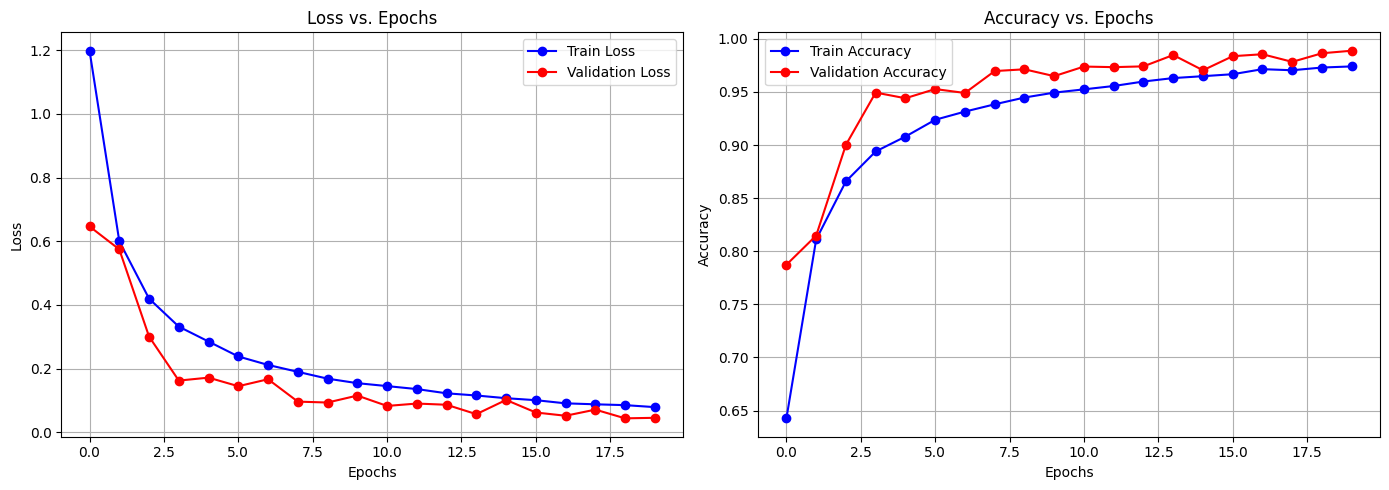

In [6]:
# Plotting Loss and Accuracy side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Loss Plot
ax[0].plot(history["train_loss"], label="Train Loss", color="blue", marker="o")
ax[0].plot(history["val_loss"], label="Validation Loss", color="red", marker="o")
ax[0].set_title("Loss vs. Epochs")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# Accuracy Plot
ax[1].plot(history["train_acc"], label="Train Accuracy", color="blue", marker="o")
ax[1].plot(history["val_acc"], label="Validation Accuracy", color="red", marker="o")
ax[1].set_title("Accuracy vs. Epochs")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Detailed Evaluation
Using the independent test set to generate a Confusion Matrix and Classification Report. This provides a deep dive into how well the model predicts each individual plant and disease class.

C:\Users\YASH\AppData\Local\Temp\ipykernel_18716\2957720309.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


Running evaluation on Test Set...

--- Classification Report ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.93      0.96        72
                                 Apple___Black_rot       0.98      1.00      0.99        64
                          Apple___Cedar_apple_rust       1.00      0.96      0.98        23
                                   Apple___healthy       1.00      1.00      1.00       169
                               Blueberry___healthy       1.00      1.00      1.00       130
          Cherry_(including_sour)___Powdery_mildew       0.99      0.97      0.98       116
                 Cherry_(including_sour)___healthy       0.99      1.00      0.99        82
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.91      0.91        45
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       113
              

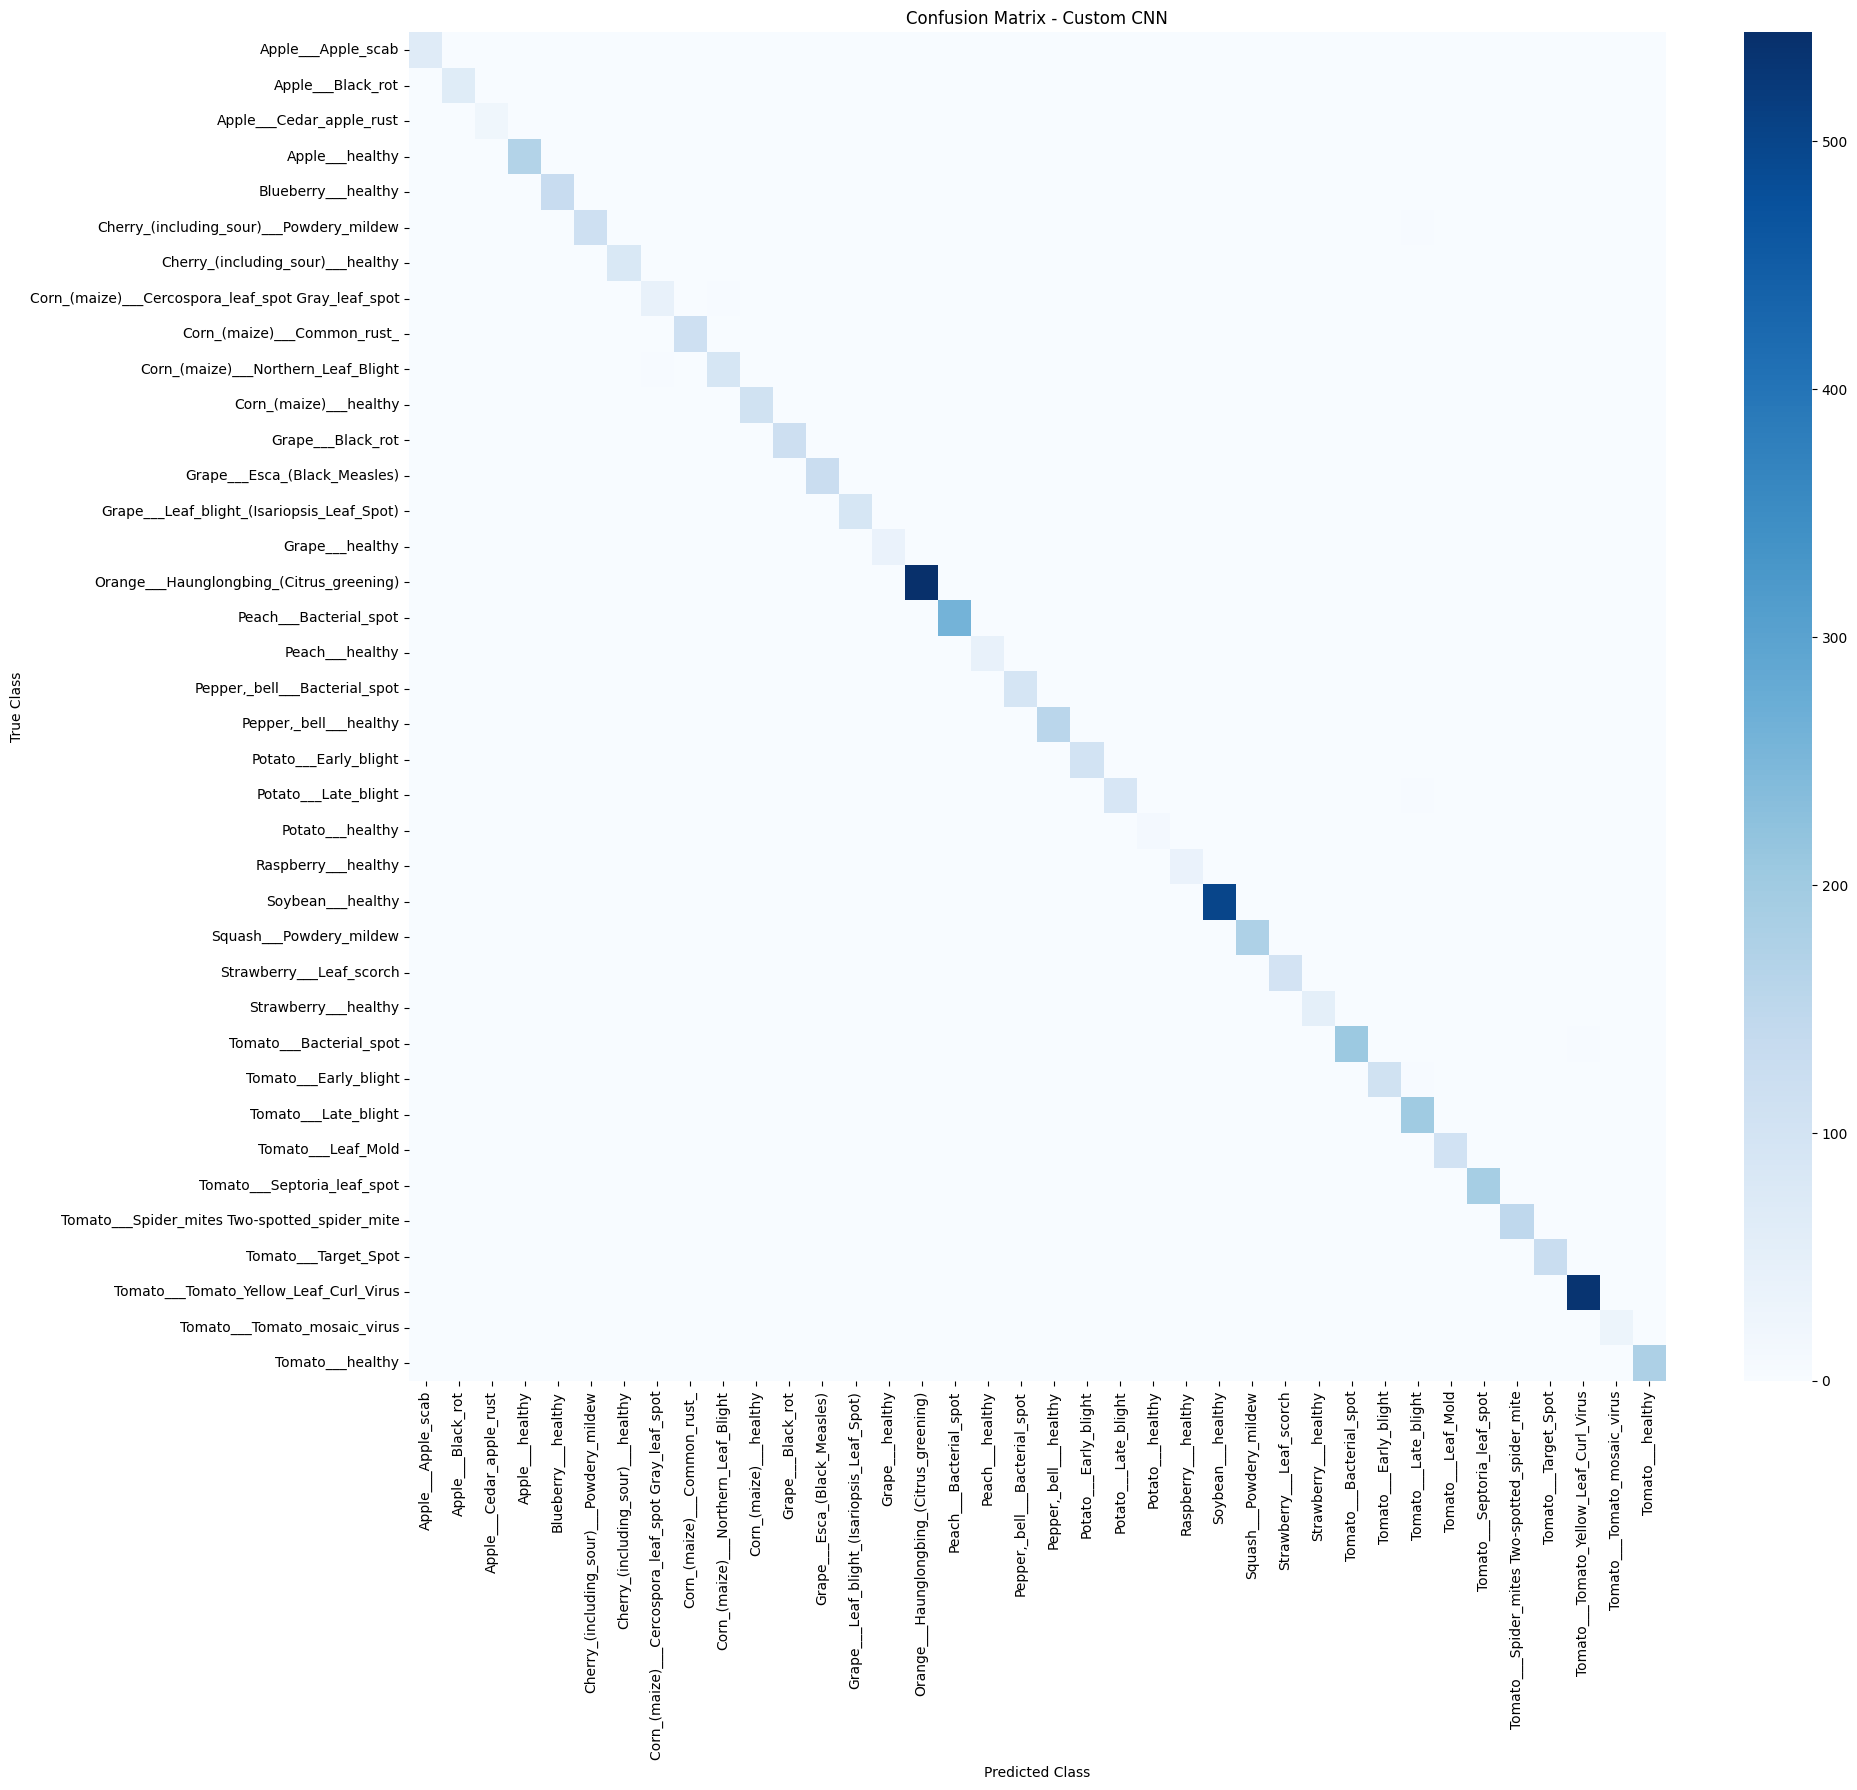

In [7]:
# Load the best weights saved during training
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []

print("Running evaluation on Test Set...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate Classification Report
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Generate and plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 18))
sns.heatmap(
    cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names
)
plt.title("Confusion Matrix - Custom CNN")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## ⏭️ Next Steps
The custom CNN successfully trained and achieved a very strong validation accuracy. We have successfully completed **Objectives 3 and 4**. 
The model is saved as `models/custom_cnn.pth`.

**Moving Forward:** In the next notebook (`03_resnet50_transfer.ipynb`), we will tackle **Objective 6 (Advanced Optimization)** by implementing Transfer Learning using a pre-trained ResNet50 model to compare performance.